# Binary Classification Model for Creditworthiness Prediction

This notebook demonstrates the complete machine learning workflow to predict whether an individual is creditworthy (1 = creditworthy, 0 = not creditworthy) based on their financial history. We use the **German Credit Dataset** from the UCI Machine Learning Repository (fetched via OpenML).

### Workflow Steps:
1. **Load and Explore** the dataset (shape, dtypes, missing values, class distribution).
2. **Exploratory Data Analysis (EDA)**: Plot class distribution, correlation heatmap, and feature distributions.
3. **Train-Test Split**: Stratified 80/20 split.
4. **Data Preprocessing**: Encode categorical variables using `OneHotEncoder` and scale numerical features using `StandardScaler` (wrapped in a `ColumnTransformer` to avoid data leakage).
5. **Address Class Imbalance**: Apply SMOTE only to the training subset (`X_train`, `y_train`).
6. **Model Training & Comparison**: Train and compare Logistic Regression, Decision Tree (max_depth=5), Random Forest (n_estimators=100), and XGBoost (n_estimators=100).
7. **Model Evaluation**: Calculate Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, and plot ROC curves.
8. **Hyperparameter Tuning**: Perform GridSearchCV on the best baseline model (dynamic parameter grids support XGBoost, Random Forest, Logistic Regression, and Decision Tree).
9. **Report Final Metrics & Feature Importances**.
10. **Save the Final Pipeline** using `joblib`.
11. **Sample Prediction Demo**: Predict on a test sample and custom user input.
12. **Final Model Comparison Summary**: Present a styled summary table marking the best performing model.

## Step 0: Environment Setup and Imports

We start by installing any required libraries and importing the necessary modules.

In [1]:
# Install dependencies if needed
!pip install xgboost imbalanced-learn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")

## Step 1: Load and Explore the Dataset

We load the German Credit Dataset from OpenML (`credit-g`). It contains 1000 instances with 20 features (7 numerical, 13 categorical) and a class target representing credit risk ('good' or 'bad').

In [3]:
# Fetch the German Credit dataset from OpenML
german_credit = fetch_openml('credit-g', version=1, as_frame=True, parser='auto')
df = german_credit.frame

# Display basic details
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [4]:
# Map target class to binary numeric format:
# 'good' -> 1 (creditworthy), 'bad' -> 0 (not creditworthy)
df['class'] = df['class'].map({'good': 1, 'bad': 0}).astype(int)

# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# Check data types and class distribution
print("\nData Types:")
print(df.dtypes.value_counts())

print("\nClass Distribution:")
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True))

Missing Values per Column:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

Data Types:
int64       8
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

Class Distribution:
class
1    700
0    300
Name: count, dtype: int64
class
1    0.7
0    0.3
Name: proportion, dtype: float64


## Step 2: Exploratory Data Analysis (EDA)

We visualize key characteristics: class distribution, correlation between numerical variables, and distributions of key features.

C:\Users\Dell\AppData\Local\Temp\ipykernel_27020\1090285652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


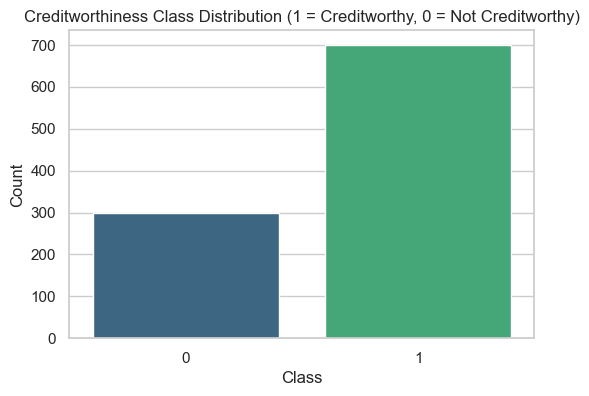

In [5]:
# Plot Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Creditworthiness Class Distribution (1 = Creditworthy, 0 = Not Creditworthy)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

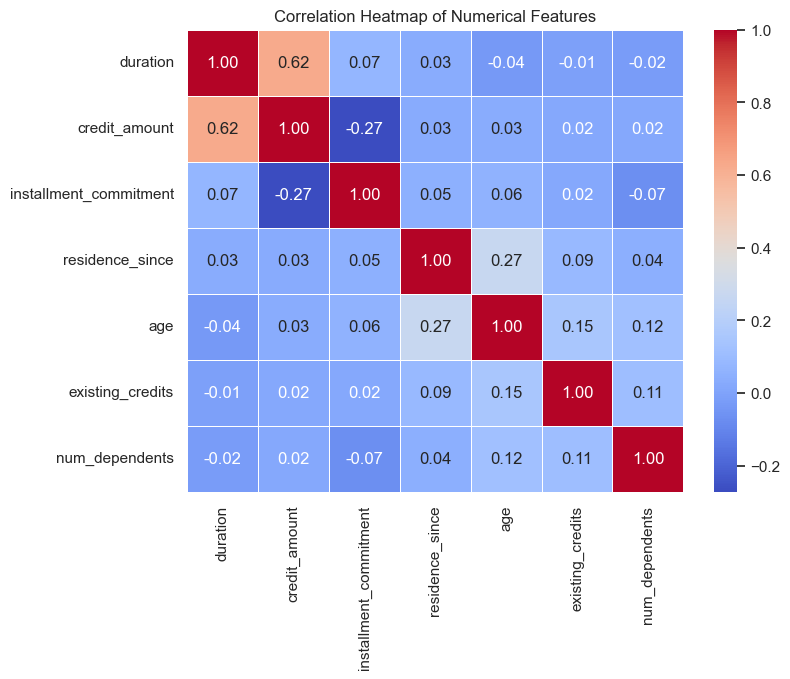

In [6]:
# Correlation heatmap for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('class') # Exclude target

plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

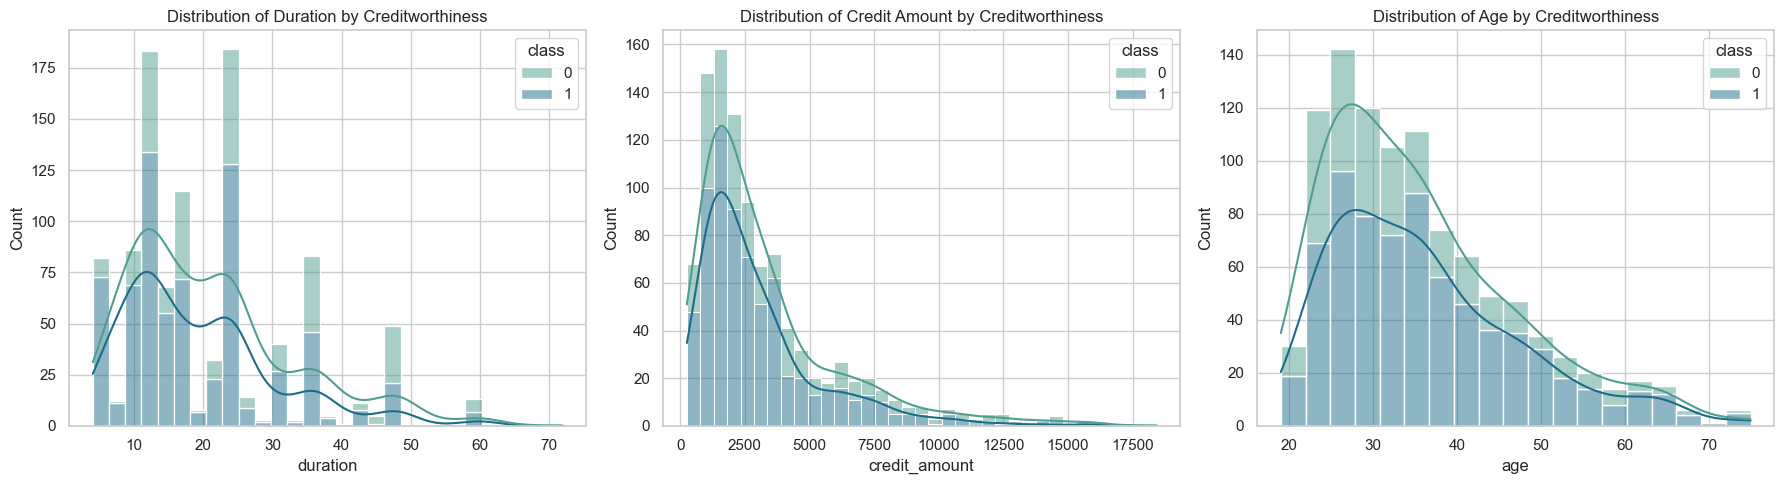

In [7]:
# Key Numerical Feature Distributions stratified by class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='duration', hue='class', kde=True, multiple='stack', ax=axes[0], palette='crest')
axes[0].set_title('Distribution of Duration by Creditworthiness')

sns.histplot(data=df, x='credit_amount', hue='class', kde=True, multiple='stack', ax=axes[1], palette='crest')
axes[1].set_title('Distribution of Credit Amount by Creditworthiness')

sns.histplot(data=df, x='age', hue='class', kde=True, multiple='stack', ax=axes[2], palette='crest')
axes[2].set_title('Distribution of Age by Creditworthiness')

plt.tight_layout()
plt.show()

## Step 3: Train-Test Split

To ensure proper verification and avoid data leakage, we perform a stratified 80/20 train-test split **before** any transformations or resampling (like SMOTE). This guarantees that the test set remains completely unseen.

In [8]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 20)
Testing set shape: (200, 20)


## Step 4: Preprocessing

We use a `ColumnTransformer` to combine preprocessings:
- Scaling numerical columns using `StandardScaler`.
- One-hot encoding categorical columns using `OneHotEncoder`.

We fit the pipeline on `X_train` and transform both `X_train` and `X_test`.

In [9]:
# Identify column types
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Set up the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Fit on training and transform both sets
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Get updated feature names
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
feature_names = numerical_cols + encoded_cat_features

X_train_preprocessed = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=feature_names)

print("Shape after preprocessing:", X_train_preprocessed.shape)

Shape after preprocessing: (800, 61)


## Step 5: Address Class Imbalance using SMOTE

We apply SMOTE **ONLY** to the training data. This balances the distribution of classes (70% creditworthy and 30% not creditworthy in the raw data) so that models do not bias predictions toward the majority class.

In [10]:
print("Class distribution in train set before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)

print("\nClass distribution in train set after SMOTE:")
print(y_train_res.value_counts())

Class distribution in train set before SMOTE:
class
1    560
0    240
Name: count, dtype: int64

Class distribution in train set after SMOTE:
class
1    560
0    560
Name: count, dtype: int64


## Step 6: Train Baseline Models

We fit four algorithms on the resampled training set:
1. **Logistic Regression** (solver='lbfgs', max_iter=1000)
2. **Decision Tree** (max_depth=5)
3. **Random Forest** (n_estimators=100)
4. **XGBoost** (n_estimators=100, eval_metric='logloss')

In [11]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
}

# Fit models on SMOTE-resampled training data (using raw NumPy array to avoid feature name characters like '<')
for name, model in models.items():
    model.fit(X_train_res.values, y_train_res.values)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.


## Step 7: Evaluate Baseline Models

We evaluate each baseline model on the unseen test set using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices.

In [12]:
metrics_dict = {}

for name, model in models.items():
    y_pred = model.predict(X_test_preprocessed.values)
    y_prob = model.predict_proba(X_test_preprocessed.values)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    metrics_dict[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc_score
    }

metrics_df = pd.DataFrame(metrics_dict).T
print("Baseline Models Metrics (Test Set):")
metrics_df

Baseline Models Metrics (Test Set):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.700,0.844828,0.700000,0.765625,0.753690
Decision Tree,0.665,0.854369,0.628571,0.724280,0.707381
Random Forest,0.725,0.781457,0.842857,0.810997,0.775833
XGBoost,0.730,0.790541,0.835714,0.812500,0.744762


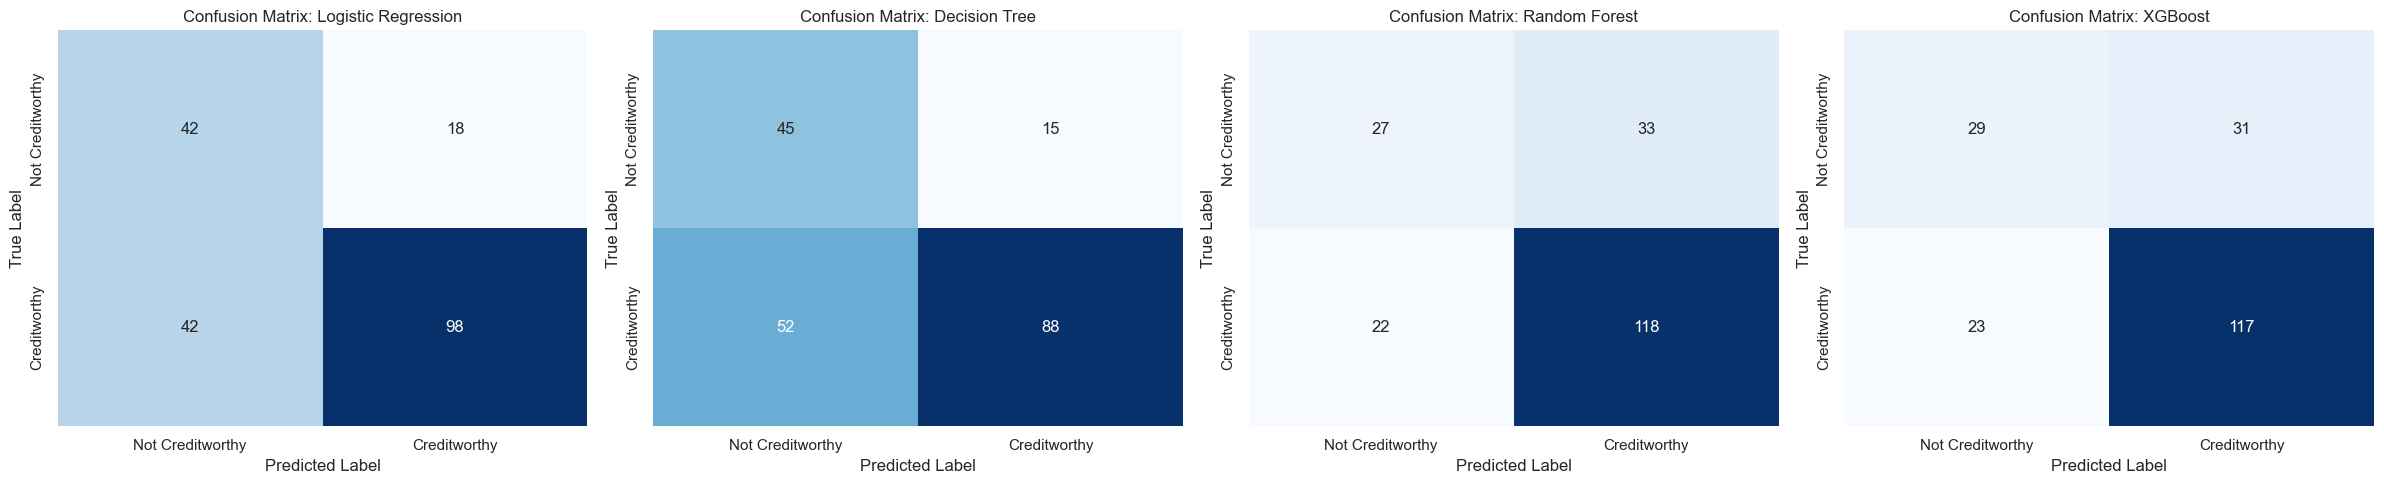

In [13]:
# Confusion Matrices (1x4 Subplots)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_preprocessed.values)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['Not Creditworthy', 'Creditworthy'])
    axes[idx].set_yticklabels(['Not Creditworthy', 'Creditworthy'])

plt.tight_layout()
plt.show()

## Step 8: Plot ROC Curves

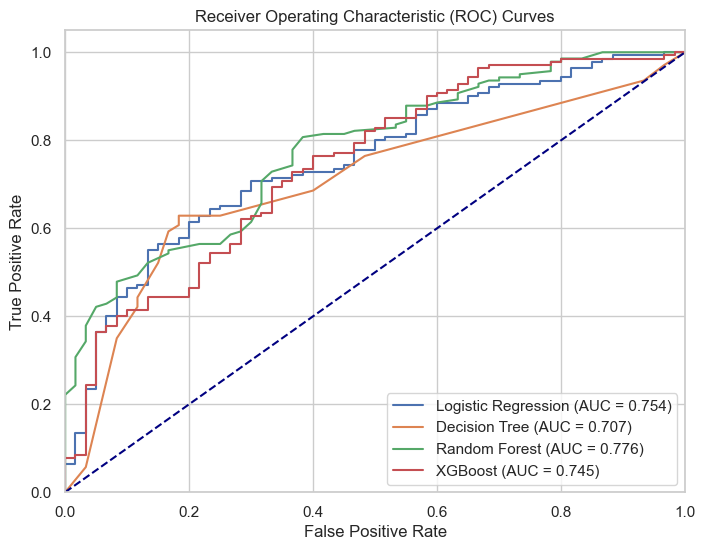

In [14]:
# Plot all ROC curves on a single plot
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_preprocessed.values)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

## Step 9: Hyperparameter Tuning using GridSearchCV

We select the best performing model based on test ROC-AUC and perform hyperparameter tuning using GridSearchCV with 5-fold cross-validation on the resampled training dataset.

Dynamic tuning support is included for XGBoost, Random Forest, Logistic Regression, and Decision Tree.

In [15]:
# Find best model name dynamically
best_model_name = metrics_df['ROC-AUC'].idxmax()
print(f"Best baseline model based on ROC-AUC: {best_model_name}\n")

# Define parameters based on best model
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 8, 12, 16],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2', None]
    }
    base_estimator = RandomForestClassifier(random_state=42)
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    base_estimator = XGBClassifier(eval_metric='logloss', random_state=42)
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'solver': ['liblinear', 'saga']
    }
    base_estimator = LogisticRegression(random_state=42, max_iter=1000)
else:
    param_grid = {
        'max_depth': [3, 5, 10, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'criterion': ['gini', 'entropy']
    }
    base_estimator = DecisionTreeClassifier(random_state=42)

# Instantiate GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Run GridSearch (on numpy arrays)
grid_search.fit(X_train_res.values, y_train_res.values)
best_tuned_model = grid_search.best_estimator_

print("\nBest parameters found:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Best baseline model based on ROC-AUC: Random Forest

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found: {'max_depth': 16, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.9269


## Step 10: Final Model Metrics and Feature Importances

In [16]:
# Predict on test set
y_pred_tuned = best_tuned_model.predict(X_test_preprocessed.values)
y_prob_tuned = best_tuned_model.predict_proba(X_test_preprocessed.values)[:, 1]

# Report classification metrics
print(f"Tuned {best_model_name} Test Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Not Creditworthy', 'Creditworthy']))

Tuned Random Forest Test Metrics:
Accuracy:  0.7400
Precision: 0.7933
Recall:    0.8500
F1-Score:  0.8207
ROC-AUC:   0.7951

Classification Report:
                  precision    recall  f1-score   support

Not Creditworthy       0.58      0.48      0.53        60
    Creditworthy       0.79      0.85      0.82       140

        accuracy                           0.74       200
       macro avg       0.69      0.67      0.67       200
    weighted avg       0.73      0.74      0.73       200



C:\Users\Dell\AppData\Local\Temp\ipykernel_27020\1402958175.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')


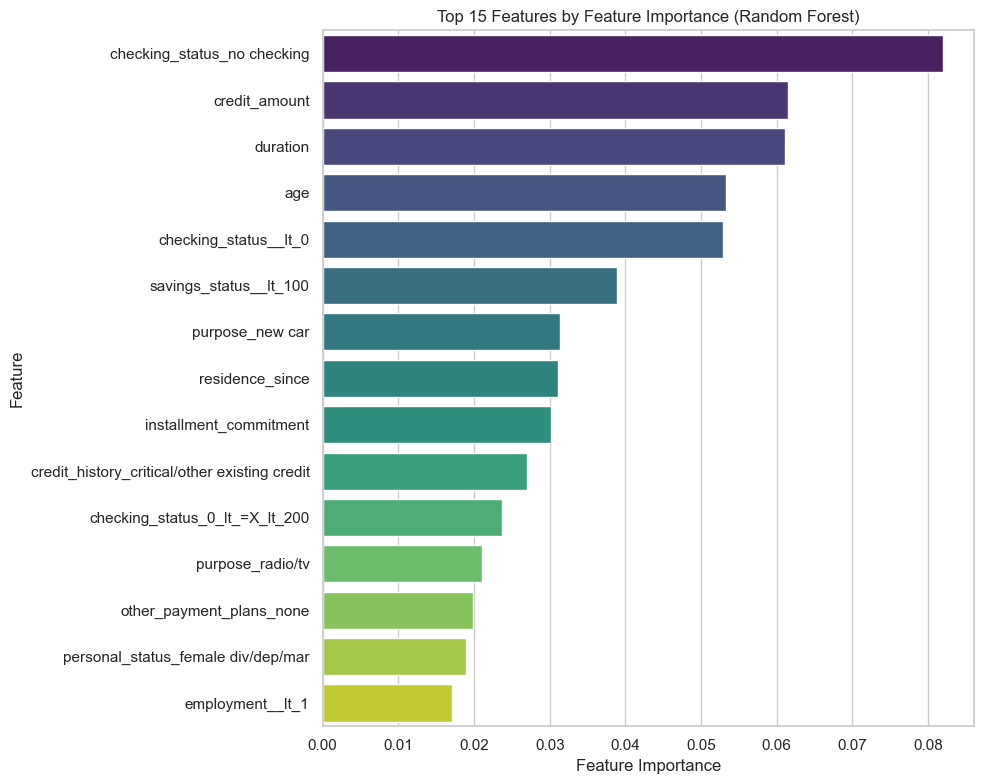

In [17]:
# Plot Feature Importances / Coefficients
if hasattr(best_tuned_model, 'feature_importances_'):
    importances = best_tuned_model.feature_importances_
    importance_type = "Feature Importance"
elif hasattr(best_tuned_model, 'coef_'):
    importances = np.abs(best_tuned_model.coef_[0])
    importance_type = "Absolute Model Coefficient (Magnitude)"
else:
    importances = None

if importances is not None:
    # Sanitize feature names for plotting
    sanitized_feature_names = [f.replace('[', '_').replace(']', '_').replace('<', '_lt_').replace('>', '_gt_') for f in feature_names]
    feat_imp_df = pd.DataFrame({
        'Feature': sanitized_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 15 Features by {importance_type} ({best_model_name})')
    plt.xlabel(importance_type)
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances/coefficients cannot be displayed for this model.")

## Step 11: Save the Final Model Pipeline

We save the complete end-to-end inference pipeline using `joblib`. This pipeline encapsulates the preprocessing transformer (`StandardScaler` and `OneHotEncoder`) and the final tuned model so that future predictions can be made directly on raw data.

In [18]:
# Build pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_tuned_model)
])

# Save to joblib file
model_filename = 'credit_scoring_model.joblib'
joblib.dump(final_pipeline, model_filename)
print(f"End-to-end inference pipeline saved successfully to '{model_filename}'")

End-to-end inference pipeline saved successfully to 'credit_scoring_model.joblib'


## Step 12: Sample Prediction Demo

In this section, we showcase how to run predictions on raw inputs using our saved `final_pipeline`. We demonstrate predictions using an actual test sample and a custom input dictionary representing a potential customer.

In [19]:
# 1. Take one raw sample from X_test (index 0)
sample_raw = X_test.iloc[[0]]
actual_label = y_test.iloc[0]

# 2. Pass it through the final pipeline
pred_label = final_pipeline.predict(sample_raw)[0]
pred_prob = final_pipeline.predict_proba(sample_raw)[0][1]

# Label mappings
label_map = {0: "Not Creditworthy", 1: "Creditworthy"}
actual_str = label_map[actual_label]
pred_str = label_map[pred_label]
confidence = pred_prob if pred_label == 1 else (1 - pred_prob)

print("="*60)
print("DEMO 1: Prediction on Unseen Test Set Sample (Index 0)")
print(f"Actual Status:    {actual_label} ({actual_str})")
print(f"Predicted Status: {pred_label} ({pred_str})")
print(f"Confidence:      {confidence:.1%}")
print("="*60)

# 5. Create a custom input dictionary
custom_input_dict = {
    'checking_status': 'no checking',
    'duration': 12,
    'credit_history': 'existing paid',
    'purpose': 'radio/tv',
    'credit_amount': 3000,
    'savings_status': 'unknown/ no savings account',
    'employment': '1<=X<4',
    'installment_commitment': 2,
    'personal_status': 'female div/dep/mar',
    'other_parties': 'none',
    'residence_since': 3,
    'property_magnitude': 'car',
    'age': 35,
    'other_payment_plans': 'none',
    'housing': 'own',
    'existing_credits': 1,
    'job': 'skilled',
    'num_dependents': 1,
    'own_telephone': 'yes',
    'foreign_worker': 'yes'
}

# Convert custom input to DataFrame and predict
custom_df = pd.DataFrame([custom_input_dict])
custom_pred = final_pipeline.predict(custom_df)[0]
custom_prob = final_pipeline.predict_proba(custom_df)[0][1]

custom_pred_str = label_map[custom_pred]
custom_confidence = custom_prob if custom_pred == 1 else (1 - custom_prob)

print("DEMO 2: Prediction on Custom User Input")
print("Input details: age=35, credit_amount=3000, duration=12, checking_status='no checking'")
print(f"Predicted Status: {custom_pred} ({custom_pred_str})")
print(f"Confidence:      {custom_confidence:.1%}")
print("="*60)

DEMO 1: Prediction on Unseen Test Set Sample (Index 0)
Actual Status:    1 (Creditworthy)
Predicted Status: 1 (Creditworthy)
Confidence:      85.3%
DEMO 2: Prediction on Custom User Input
Input details: age=35, credit_amount=3000, duration=12, checking_status='no checking'
Predicted Status: 1 (Creditworthy)
Confidence:      92.4%


## Step 13: Final Model Comparison Summary

In this final section, we aggregate and structure the metrics for all four baseline classifiers to identify the best overall classifier based on test ROC-AUC. We display the results in a styled summary table.

In [20]:
# Create final comparison table
summary_data = []
for name in metrics_df.index:
    row = {
        'Model': name,
        'Accuracy': round(metrics_df.loc[name, 'Accuracy'], 4),
        'Precision': round(metrics_df.loc[name, 'Precision'], 4),
        'Recall': round(metrics_df.loc[name, 'Recall'], 4),
        'F1-Score': round(metrics_df.loc[name, 'F1-Score'], 4),
        'ROC-AUC': round(metrics_df.loc[name, 'ROC-AUC'], 4)
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
best_auc = summary_df['ROC-AUC'].max()
summary_df['Best Model'] = summary_df['ROC-AUC'].apply(lambda x: '✅' if x == best_auc else '❌')

# Render the styled comparison table
styled_table = summary_df.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], 
    color='lightgreen'
)
display(styled_table)

# Report overall best model
best_model_name = metrics_df['ROC-AUC'].idxmax()
print(f"\nBest overall model: {best_model_name} with ROC-AUC of {best_auc:.4f}")

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Best Model
0,Logistic Regression,0.700000,0.844800,0.700000,0.765600,0.753700,❌
1,Decision Tree,0.665000,0.854400,0.628600,0.724300,0.707400,❌
2,Random Forest,0.725000,0.781500,0.842900,0.811000,0.775800,✅
3,XGBoost,0.730000,0.790500,0.835700,0.812500,0.744800,❌



Best overall model: Random Forest with ROC-AUC of 0.7758
